In [ ]:
import zipfile

with zipfile.ZipFile('/content/archive (3).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/data')


In [ ]:
import pandas as pd

ratings = pd.read_csv(
    '/content/data/ml-100k/u.data',
    sep='\t',
    names=['userId', 'movieId', 'rating', 'timestamp']
)

print(ratings.head())


   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596


In [ ]:
user_activity = ratings['userId'].value_counts()

print(user_activity.head())

print("Most active user:", user_activity.index[0])
print("Number of ratings:", user_activity.iloc[0])


userId
405    737
655    685
13     636
450    540
276    518
Name: count, dtype: int64
Most active user: 405
Number of ratings: 737


In [ ]:
user_avg_rating = ratings.groupby('userId')['rating'].mean()

print(user_avg_rating.head())


userId
1    3.610294
2    3.709677
3    2.796296
4    4.333333
5    2.874286
Name: rating, dtype: float64


In [ ]:
user_summary = pd.DataFrame({
    'num_ratings': ratings.groupby('userId').size(),
    'avg_rating': ratings.groupby('userId')['rating'].mean()
})

print(user_summary.head())


        num_ratings  avg_rating
userId                         
1               272    3.610294
2                62    3.709677
3                54    2.796296
4                24    4.333333
5               175    2.874286


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


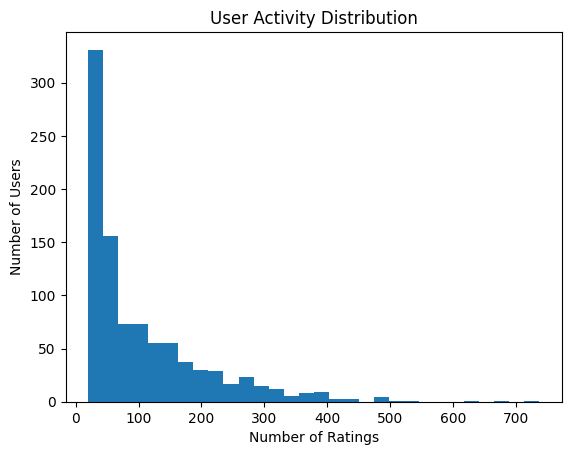

In [ ]:
import matplotlib.pyplot as plt

plt.hist(user_summary['num_ratings'], bins=30)
plt.title("User Activity Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()


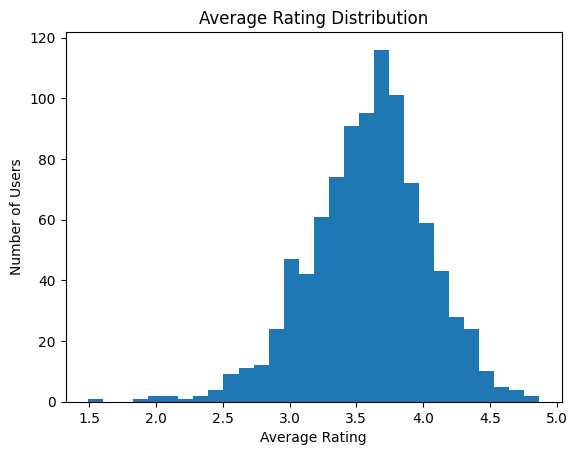

In [ ]:
plt.hist(user_summary['avg_rating'], bins=30)
plt.title("Average Rating Distribution")
plt.xlabel("Average Rating")
plt.ylabel("Number of Users")
plt.show()


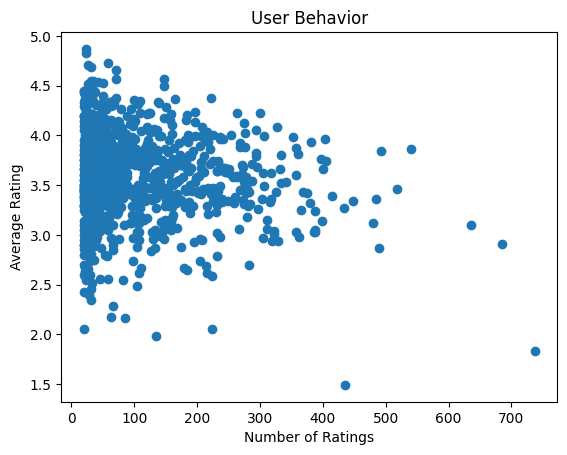

In [ ]:
plt.scatter(user_summary['num_ratings'], user_summary['avg_rating'])
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.title("User Behavior")
plt.show()


In [ ]:
def classify_user(row):
    if row['num_ratings'] > 200 and row['avg_rating'] > 3.5:
        return "Loyal Users"
    elif row['num_ratings'] > 200 and row['avg_rating'] <= 3.5:
        return "Critical Users"
    elif row['num_ratings'] <= 200 and row['avg_rating'] > 3.5:
        return "Casual Happy Users"
    else:
        return "At-Risk Users"

user_summary['user_type'] = user_summary.apply(classify_user, axis=1)

print(user_summary.head())


        num_ratings  avg_rating           user_type
userId                                             
1               272    3.610294         Loyal Users
2                62    3.709677  Casual Happy Users
3                54    2.796296       At-Risk Users
4                24    4.333333  Casual Happy Users
5               175    2.874286       At-Risk Users


In [ ]:
print(user_summary['user_type'].value_counts())


user_type
Casual Happy Users    495
At-Risk Users         300
Critical Users         77
Loyal Users            71
Name: count, dtype: int64


In [ ]:
print("INSIGHT:")
print("The platform has a small number of highly active users and many low-activity users.")
print("This suggests that increasing engagement of casual users could significantly grow the platform.")


INSIGHT:
The platform has a small number of highly active users and many low-activity users.
This suggests that increasing engagement of casual users could significantly grow the platform.


In [ ]:
print("BUSINESS INSIGHTS:")

print("- Most users are low activity, meaning engagement is a challenge.")
print("- Loyal users are few but very valuable.")
print("- At-risk users represent a potential loss for the platform.")

print("\nRECOMMENDATIONS:")

print("- Recommend more personalized content to casual users.")
print("- Offer incentives to at-risk users.")
print("- Maintain high-quality recommendations for loyal users.")


BUSINESS INSIGHTS:
- Most users are low activity, meaning engagement is a challenge.
- Loyal users are few but very valuable.
- At-risk users represent a potential loss for the platform.

RECOMMENDATIONS:
- Recommend more personalized content to casual users.
- Offer incentives to at-risk users.
- Maintain high-quality recommendations for loyal users.


In [ ]:
from sklearn.preprocessing import StandardScaler

features = user_summary[['num_ratings', 'avg_rating']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
user_summary['cluster'] = kmeans.fit_predict(scaled_features)

print(user_summary.head())


        num_ratings  avg_rating           user_type  cluster
userId                                                      
1               272    3.610294         Loyal Users        0
2                62    3.709677  Casual Happy Users        1
3                54    2.796296       At-Risk Users        2
4                24    4.333333  Casual Happy Users        3
5               175    2.874286       At-Risk Users        2


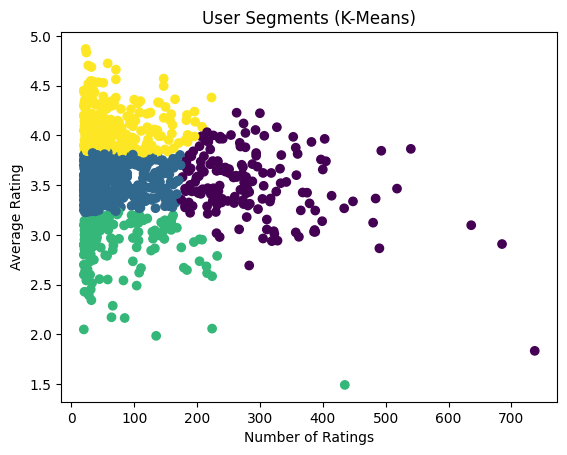

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(user_summary['num_ratings'], user_summary['avg_rating'],
            c=user_summary['cluster'])

plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.title("User Segments (K-Means)")
plt.show()


In [ ]:
cluster_summary = user_summary.groupby('cluster')[['num_ratings', 'avg_rating']].mean()

print(cluster_summary)


         num_ratings  avg_rating
cluster                         
0         285.218750    3.517313
1          66.527132    3.556460
2          77.442953    2.905157
3          69.149798    4.095853


In [ ]:
print(user_summary.groupby('cluster').size())


cluster
0    160
1    387
2    149
3    247
dtype: int64


In [ ]:
def name_cluster(row):
    if row['num_ratings'] > 200 and row['avg_rating'] > 3.5:
        return "Power Users"
    elif row['num_ratings'] > 200:
        return "Engaged but Critical"
    elif row['avg_rating'] > 3.5:
        return "Casual Fans"
    else:
        return "Low Engagement Users"

user_summary['cluster_name'] = user_summary.apply(name_cluster, axis=1)

print(user_summary['cluster_name'].value_counts())


cluster_name
Casual Fans             495
Low Engagement Users    300
Engaged but Critical     77
Power Users              71
Name: count, dtype: int64


In [ ]:
print("KEY INSIGHT:")

print("Majority of the users are casual viewers who enjoy content but are not highly engaged.")
print("A significant portion of users show low engagement, indicating a risk of churn.")
print("Only a small percentage of users are highly active power users, but they contribute heavily to platform activity.")


KEY INSIGHT:
Majority of the users are casual viewers who enjoy content but are not highly engaged.
A significant portion of users show low engagement, indicating a risk of churn.
Only a small percentage of users are highly active power users, but they contribute heavily to platform activity.


In [ ]:
movies = pd.read_csv(
    '/content/data/ml-100k/u.item',
    sep='|',
    encoding='latin-1',
    header=None
)

movies = movies[[0, 1]]
movies.columns = ['movieId', 'title']

print(movies.head())


   movieId              title
0        1   Toy Story (1995)
1        2   GoldenEye (1995)
2        3  Four Rooms (1995)
3        4  Get Shorty (1995)
4        5     Copycat (1995)


In [ ]:
data = pd.merge(ratings, movies, on='movieId')

print(data.head())


   userId  movieId  rating  timestamp                       title
0     196      242       3  881250949                Kolya (1996)
1     186      302       3  891717742    L.A. Confidential (1997)
2      22      377       1  878887116         Heavyweights (1994)
3     244       51       2  880606923  Legends of the Fall (1994)
4     166      346       1  886397596         Jackie Brown (1997)


In [ ]:
popular_movies = data['title'].value_counts()

print(popular_movies.head(10))


title
Star Wars (1977)                 583
Contact (1997)                   509
Fargo (1996)                     508
Return of the Jedi (1983)        507
Liar Liar (1997)                 485
English Patient, The (1996)      481
Scream (1996)                    478
Toy Story (1995)                 452
Air Force One (1997)             431
Independence Day (ID4) (1996)    429
Name: count, dtype: int64


In [ ]:
movie_ratings = data.groupby('title')['rating'].mean()
movie_counts = data['title'].value_counts()

movie_summary = pd.DataFrame({
    'avg_rating': movie_ratings,
    'num_ratings': movie_counts
})

# filter for reliable movies
top_movies = movie_summary[movie_summary['num_ratings'] > 100]

print(top_movies.sort_values(by='avg_rating', ascending=False).head(10))


                                  avg_rating  num_ratings
title                                                    
Close Shave, A (1995)               4.491071          112
Schindler's List (1993)             4.466443          298
Wrong Trousers, The (1993)          4.466102          118
Casablanca (1942)                   4.456790          243
Shawshank Redemption, The (1994)    4.445230          283
Rear Window (1954)                  4.387560          209
Usual Suspects, The (1995)          4.385768          267
Star Wars (1977)                    4.358491          583
12 Angry Men (1957)                 4.344000          125
Citizen Kane (1941)                 4.292929          198


In [ ]:
print("CONTENT STRATEGY INSIGHT:")

print("Popular movies drive user engagement and should therefore be promoted.")
print("Highly rated movies should be recommended more frequently.")
print("Combining both popularity and rating can improve recommendation systems.")


CONTENT STRATEGY INSIGHT:
Popular movies drive user engagement and should therefore be promoted.
Highly rated movies should be recommended more frequently.
Combining both popularity and rating can improve recommendation systems.


In [ ]:
print("INSIGHTS:")

print("- Classic and highly rated movies dominate the top rankings.")
print("- Popular movies with many ratings tend to also have high average ratings.")
print("- Well-known films are consistently preferred by users.")


INSIGHTS:
- Classic and highly rated movies dominate the top rankings.
- Popular movies with many ratings tend to also have high average ratings.
- Well-known films are consistently preferred by users.


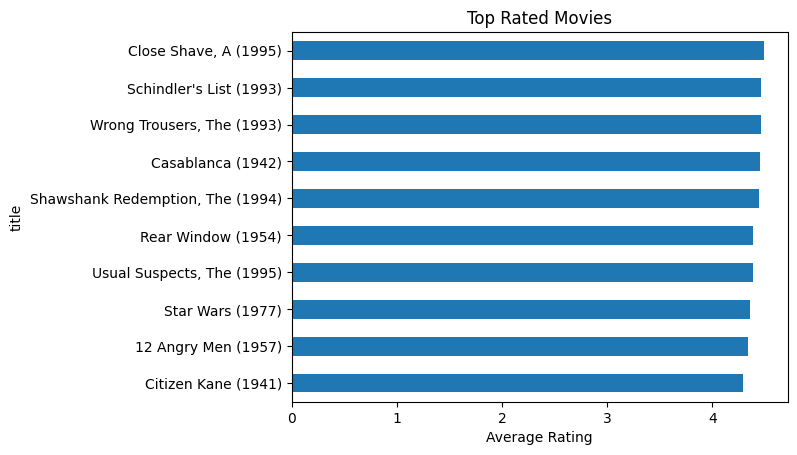

In [ ]:
top_10 = top_movies.sort_values(by='avg_rating', ascending=False).head(10)

top_10['avg_rating'].plot(kind='barh')

plt.title("Top Rated Movies")
plt.xlabel("Average Rating")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
print("ADVANCED INSIGHTS:")

print("- Popular movies can be used to engage new or inactive users.")
print("- Different user segments should receive different recommendations.")


ADVANCED INSIGHTS:
- Popular movies can be used to engage new or inactive users.
- Different user segments should receive different recommendations.
